Starting Training...
Epoch 01/20 | Loss: 0.5668 | Accuracy: 71.1%
Epoch 02/20 | Loss: 0.2157 | Accuracy: 91.9%
Epoch 03/20 | Loss: 0.1825 | Accuracy: 92.5%
Epoch 04/20 | Loss: 0.1709 | Accuracy: 93.1%
Epoch 05/20 | Loss: 0.1640 | Accuracy: 93.2%
Epoch 06/20 | Loss: 0.1588 | Accuracy: 93.9%
Epoch 07/20 | Loss: 0.1545 | Accuracy: 94.0%
Epoch 08/20 | Loss: 0.1506 | Accuracy: 94.1%
Epoch 09/20 | Loss: 0.1470 | Accuracy: 94.2%
Epoch 10/20 | Loss: 0.1437 | Accuracy: 94.5%
Epoch 11/20 | Loss: 0.1407 | Accuracy: 94.7%
Epoch 12/20 | Loss: 0.1379 | Accuracy: 94.6%
Epoch 13/20 | Loss: 0.1354 | Accuracy: 94.9%
Epoch 14/20 | Loss: 0.1332 | Accuracy: 94.7%
Epoch 15/20 | Loss: 0.1313 | Accuracy: 95.1%
Epoch 16/20 | Loss: 0.1297 | Accuracy: 94.9%
Epoch 17/20 | Loss: 0.1283 | Accuracy: 94.6%
Epoch 18/20 | Loss: 0.1269 | Accuracy: 94.9%
Epoch 19/20 | Loss: 0.1255 | Accuracy: 94.8%
Epoch 20/20 | Loss: 0.1238 | Accuracy: 94.7%


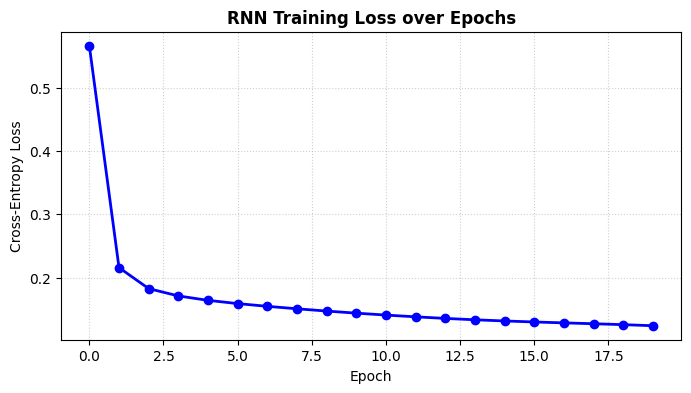

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── Reproducibility ───────────────────────────────────────────────────────────
rng = np.random.default_rng(42)

# ── 1. DATASET GENERATION ─────────────────────────────────────────────────────
def generate_sequence_data(num_samples, seq_len, input_dim):
    """
    Generates a dataset where the target class is 1 if the sum of the
    sequence (across all timesteps and features) is > 0, else 0.
    """
    X = rng.normal(scale=1.0, size=(num_samples, seq_len, input_dim))
    # Target is 1 if the sum of the sequence is positive, else 0
    sums = X.sum(axis=(1, 2))
    y = (sums > 0).astype(int)
    return X, y

# ── 2. RNN CLASS (FORWARD & BACKWARD PASS) ────────────────────────────────────
class VanillaRNN:
    def __init__(self, input_dim, hidden_dim, output_dim, learning_rate=0.01):
        self.hidden_dim = hidden_dim
        self.lr = learning_rate

        # Xavier/Glorot-style initialization
        limit_h = np.sqrt(1 / hidden_dim)
        limit_x = np.sqrt(1 / input_dim)

        self.W_xh = rng.uniform(-limit_x, limit_x, size=(input_dim, hidden_dim))
        self.W_hh = rng.uniform(-limit_h, limit_h, size=(hidden_dim, hidden_dim))
        self.W_hy = rng.uniform(-limit_h, limit_h, size=(hidden_dim, output_dim))
        self.b_h  = np.zeros(hidden_dim)
        self.b_y  = np.zeros(output_dim)

    def _softmax(self, z):
        exp_z = np.exp(z - z.max()) # Numerical stability
        return exp_z / exp_z.sum()

    def forward(self, sequence):
        """Forward pass storing intermediate states for Backprop."""
        self.xs = []
        self.hs = [np.zeros(self.hidden_dim)] # Initialize h_0

        for x_t in sequence:
            pre_activation = x_t @ self.W_xh + self.hs[-1] @ self.W_hh + self.b_h
            h_t = np.tanh(pre_activation)

            self.xs.append(x_t)
            self.hs.append(h_t)

        # Final output uses the last hidden state
        logits = self.hs[-1] @ self.W_hy + self.b_y
        self.probs = self._softmax(logits)

        return self.probs

    def backward(self, target):
        """Backpropagation Through Time (BPTT)."""
        # 1. Gradients at the output layer (Cross-Entropy + Softmax derivative)
        dy = self.probs.copy()
        dy[target] -= 1.0  # (probs - one_hot_target)

        dW_hy = np.outer(self.hs[-1], dy)
        db_y  = dy

        # 2. Backpropagate into the hidden state
        dh_next = self.W_hy @ dy

        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        db_h  = np.zeros_like(self.b_h)

        # 3. Loop backwards through time
        for t in reversed(range(len(self.xs))):
            h_t = self.hs[t+1]
            h_prev = self.hs[t]
            x_t = self.xs[t]

            # Derivative of tanh: (1 - tanh^2)
            dtanh = dh_next * (1 - h_t**2)

            # Accumulate gradients for weights
            dW_xh += np.outer(x_t, dtanh)
            dW_hh += np.outer(h_prev, dtanh)
            db_h  += dtanh

            # Pass gradient to previous timestep
            dh_next = self.W_hh @ dtanh

        # 4. Gradient Clipping (Crucial to prevent exploding gradients in RNNs)
        for d in [dW_xh, dW_hh, dW_hy, db_h, db_y]:
            np.clip(d, -5, 5, out=d)

        # 5. Update weights (Gradient Descent)
        self.W_xh -= self.lr * dW_xh
        self.W_hh -= self.lr * dW_hh
        self.W_hy -= self.lr * dW_hy
        self.b_h  -= self.lr * db_h
        self.b_y  -= self.lr * db_y

# ── 3. TRAINING LOOP ──────────────────────────────────────────────────────────
if __name__ == "__main__":
    # Hyperparameters
    SEQ_LEN    = 8
    INPUT_DIM  = 3
    HIDDEN_DIM = 16
    OUTPUT_DIM = 2
    EPOCHS     = 20
    SAMPLES    = 1000

    # Generate Dataset
    X_train, y_train = generate_sequence_data(SAMPLES, SEQ_LEN, INPUT_DIM)

    # Initialize Model
    rnn = VanillaRNN(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM, learning_rate=0.005)

    epoch_losses = []

    print("Starting Training...")
    for epoch in range(EPOCHS):
        total_loss = 0
        correct = 0

        # Stochastic Gradient Descent (1 sequence at a time)
        for i in range(SAMPLES):
            x_seq = X_train[i]
            target = y_train[i]

            # Forward & Backward
            probs = rnn.forward(x_seq)
            rnn.backward(target)

            # Calculate metrics
            loss = -np.log(probs[target]) # Cross-Entropy Loss
            total_loss += loss
            if probs.argmax() == target:
                correct += 1

        avg_loss = total_loss / SAMPLES
        accuracy = correct / SAMPLES
        epoch_losses.append(avg_loss)

        print(f"Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | Accuracy: {accuracy*100:.1f}%")

    # ── 4. VISUALIZE LEARNING ─────────────────────────────────────────────────
    plt.figure(figsize=(8, 4))
    plt.plot(epoch_losses, color="blue", linewidth=2, marker='o')
    plt.title("RNN Training Loss over Epochs", fontweight="bold")
    plt.xlabel("Epoch")
    plt.ylabel("Cross-Entropy Loss")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.show()